Εικόνα ως γράφοι

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist

def image_to_graph(img_array: np.ndarray) -> np.ndarray:
    """
    Μετατρέπει μια εικόνα (M, N, C) σε fully-connected γράφο με MN κόμβους και επιστρέφει τον affinity πίνακα.

    Κάθε κόμβος είναι ένα pixel και το βάρος κάθε ακμής είναι A(i,j) = 1 / exp(d(i,j)),
    όπου d(i,j) είναι η ευκλείδεια απόσταση φωτεινότητας στο χώρο καναλιών.
    """
    M, N, C = img_array.shape
    num_pixels = M * N

    # Αναδιάταξη της εικόνας: κάθε pixel γίνεται διάνυσμα στο χώρο των C καναλιών
    pixels = img_array.reshape(-1, C)  # σχήμα: [MN, C]

    # Υπολογισμός όλων των αποστάσεων μεταξύ pixels (ευκλείδεια απόσταση)
    dist_matrix = cdist(pixels, pixels, metric='euclidean')  # σχήμα: [MN, MN]

    # Υπολογισμός affinity: A(i,j) = 1 / exp(d(i,j)) = exp(-d(i,j))
    affinity_mat = np.exp(-dist_matrix)

    return affinity_mat


Spectral Clustering

In [ ]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans
import numpy as np

def spectral_clustering(affinity_mat: np.ndarray, k: int) -> np.ndarray:
    # Μετατροπή affinity σε sparse
    affinity_sparse = csr_matrix(affinity_mat)

    # Κατασκευή Laplacian: L = D - W
    degrees = np.array(affinity_sparse.sum(axis=1)).flatten()
    D = csr_matrix(np.diag(degrees))
    L = D - affinity_sparse

    # Υπολογισμός των k μικρότερων ιδιοδιανυσμάτων (excluding trivial 0)
    eigvals, eigvecs = eigsh(L, k=k, which='SM')  # SM = smallest magnitude

    # Κανονικοποίηση (προαιρετική αλλά χρήσιμη για k-means)
    U = eigvecs
    U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

    # K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(U_norm)

    return kmeans.labels_


In [ ]:
from scipy.io import loadmat
import numpy as np

# Βήμα 2: Φόρτωσε τα περιεχόμενα του .mat αρχείου
data = loadmat("dip_hw_3.mat")  # όνομα αρχείου όπως το ανέβασες

# Βήμα 3: Πάρε τον affinity πίνακα από το πεδίο 'd1a'
affinity_mat = data["d1a"]

# Προαιρετικά: έλεγχος διαστάσεων
print("Affinity matrix shape:", affinity_mat.shape)

# Για κάθε k, εκτέλεσε spectral clustering
for k in [2, 3, 4]:
    labels = spectral_clustering(affinity_mat, k)
    print(f"Labels for k = {k}:\n{labels}\n")

Affinity matrix shape: (12, 12)
Labels for k = 2:
[1 1 1 1 0 0 0 0 1 1 1 1]

Labels for k = 3:
[2 2 2 2 0 0 0 0 1 1 1 1]

Labels for k = 4:
[1 1 1 1 2 0 2 0 3 3 3 3]



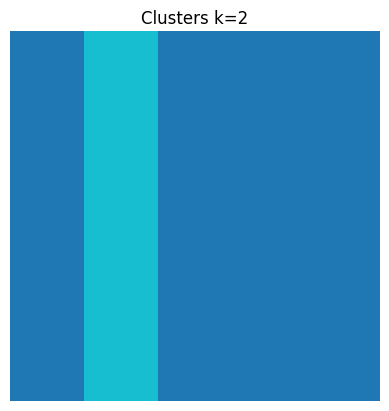

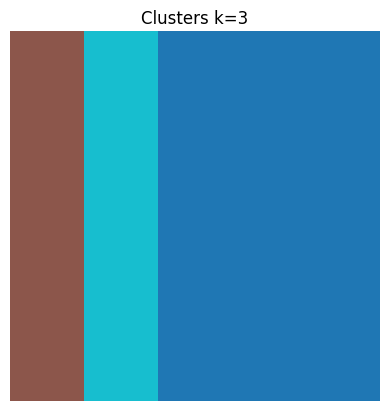

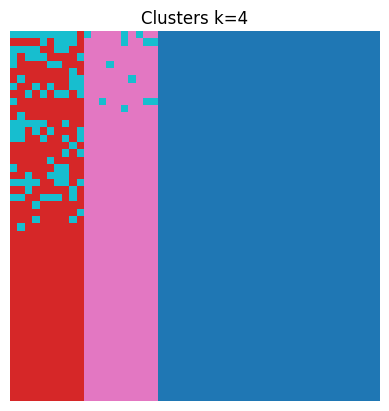

In [ ]:
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Βήμα 1: Φόρτωσε δεδομένα
data = loadmat("dip_hw_3.mat")
img_array = data["d2a"]  # ή "d2b"
img_array = img_array.astype(float) / 255.0  # κλιμάκωση [0,1]

# Βήμα 2: Χτίσε γράφο
affinity = image_to_graph(img_array)

# Βήμα 3: Εφάρμοσε για κάθε k
for k in [2, 3, 4]:
    labels = spectral_clustering(affinity, k)
    clustered = labels.reshape(img_array.shape[:2])

    # Βήμα 4: Προβολή αποτελέσματος
    plt.figure()
    plt.imshow(clustered, cmap='tab10')
    plt.title(f"Clusters k={k}")
    plt.axis("off")
    plt.show()


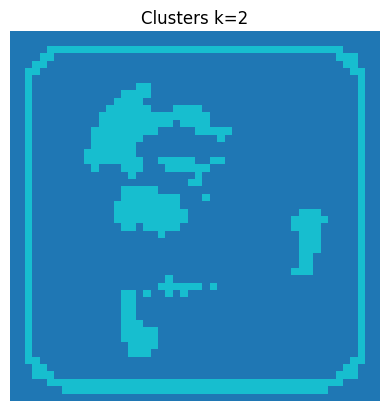

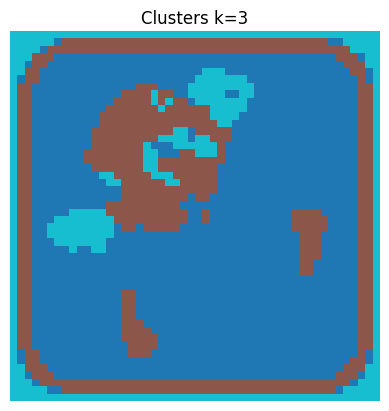

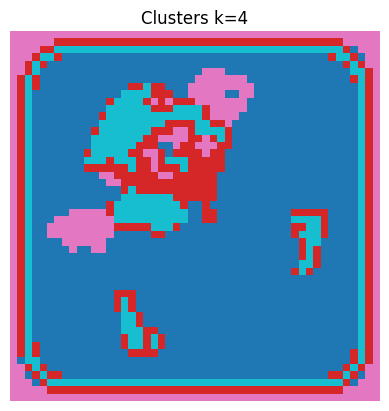

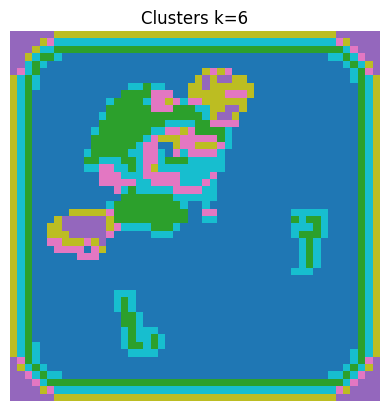

In [ ]:
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Βήμα 1: Φόρτωσε δεδομένα
data = loadmat("dip_hw_3.mat")
img_array = data["d2b"]  # ή "d2b"
img_array = img_array.astype(float) / 255.0  # κλιμάκωση [0,1]

# Βήμα 2: Χτίσε γράφο
affinity = image_to_graph(img_array)

# Βήμα 3: Εφάρμοσε για κάθε k
for k in [2, 3, 4,6]:
    labels = spectral_clustering(affinity, k)
    clustered = labels.reshape(img_array.shape[:2])

    # Βήμα 4: Προβολή αποτελέσματος
    plt.figure()
    plt.imshow(clustered, cmap='tab10')
    plt.title(f"Clusters k={k}")
    plt.axis("off")
    plt.show()


In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans

def n_cuts(affinity_mat: np.ndarray, k: int) -> np.ndarray:
    # 1. Laplacian
    W = csr_matrix(affinity_mat)
    degrees = np.array(W.sum(axis=1)).flatten()
    D = csr_matrix(np.diag(degrees))
    L = D - W

    # 2. Ιδιοτιμές/ιδιοδιανύσματα (συμμετρικός πίνακας ⇒ eigsh)
    _, eigvecs = eigsh(L, k=k, which='SM')  # παίρνει τα k smallest

    # 3. Κανονικοποίηση γραμμών (προαιρετικά αλλά βοηθάει)
    U = eigvecs
    U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

    # 4. Clustering με k-means
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(U_norm)

    return kmeans.labels_


In [ ]:
def calculate_n_cut_value(
    affinity_mat: np.ndarray,
    cluster_idx: np.ndarray
) -> float:
    W = affinity_mat
    A = np.where(cluster_idx == 0)[0]
    B = np.where(cluster_idx == 1)[0]
    V = np.arange(W.shape[0])

    # assoc(A,A) και assoc(A,V)
    assoc_A_A = np.sum(W[np.ix_(A, A)])
    assoc_A_V = np.sum(W[np.ix_(A, V)])

    # assoc(B,B) και assoc(B,V)
    assoc_B_B = np.sum(W[np.ix_(B, B)])
    assoc_B_V = np.sum(W[np.ix_(B, V)])

    # Nassoc και Ncut
    Nassoc = (assoc_A_A / assoc_A_V) + (assoc_B_B / assoc_B_V)
    Ncut = 2 - Nassoc

    return Ncut


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh

def n_cuts_recursive(affinity_mat: np.ndarray, T1: int, T2: float) -> np.ndarray:
    N = affinity_mat.shape[0]
    labels = -np.ones(N, dtype=int)  # αρχικοποίηση: όλοι χωρίς ετικέτα
    next_cluster_id = 0

    # Κάθε στοιχείο του queue είναι μια λίστα με indices κόμβων προς εξέταση
    queue = [(np.arange(N), next_cluster_id)]
    next_cluster_id += 1

    while queue:
        node_indices, cluster_id = queue.pop(0)

        # Αν το cluster είναι πολύ μικρό, δεν διαχωρίζεται άλλο
        if len(node_indices) < T1:
            labels[node_indices] = cluster_id
            continue

        # Υποσύνολο του affinity πίνακα
        sub_affinity = affinity_mat[np.ix_(node_indices, node_indices)]

        # Spectral clustering σε αυτό το υποσύνολο με k=2
        sub_labels = spectral_clustering(sub_affinity, k=2)

        # Ανακατανομή sub-labels στα αρχικά indices
        full_labels = -np.ones(N, dtype=int)
        full_labels[node_indices] = sub_labels

        # Υπολογισμός Ncut
        ncut_val = calculate_n_cut_value(affinity_mat, full_labels)

        if ncut_val > T2:
            # Δεν επιτρέπεται διαχωρισμός → δώσε κοινή ετικέτα
            labels[node_indices] = cluster_id
        else:
            # Διαχωρισμός γίνεται → προώθησε τα δύο νέα subsets
            group_0 = node_indices[sub_labels == 0]
            group_1 = node_indices[sub_labels == 1]
            queue.append((group_0, next_cluster_id))
            next_cluster_id += 1
            queue.append((group_1, next_cluster_id))
            next_cluster_id += 1

    return labels



--- Image: d2a ---

[NCuts] Clustering with k = 2
Ncut value (k=2): 0.9986

[NCuts] Clustering with k = 3

[NCuts] Clustering with k = 4

[n_cuts_recursive] Recursive clustering:
Generated clusters: 1

--- Image: d2b ---

[NCuts] Clustering with k = 2
Ncut value (k=2): 0.9994

[NCuts] Clustering with k = 3

[NCuts] Clustering with k = 4

[n_cuts_recursive] Recursive clustering:
Generated clusters: 1

--- Demo 3b: One split only ---

Image: d2a

Image: d2b

--- Demo 3c: Full Recursive N-Cuts vs Spectral Clustering ---

Image: d2a
Recursive n-cuts produced 1 clusters

Image: d2b
Recursive n-cuts produced 1 clusters


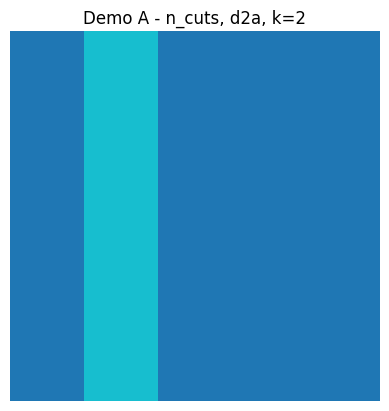

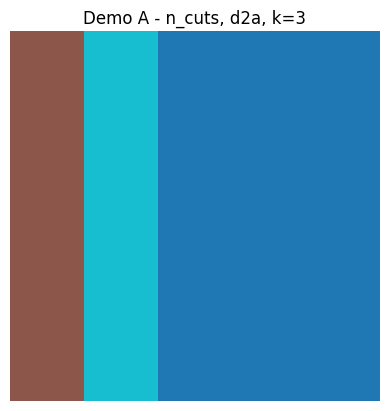

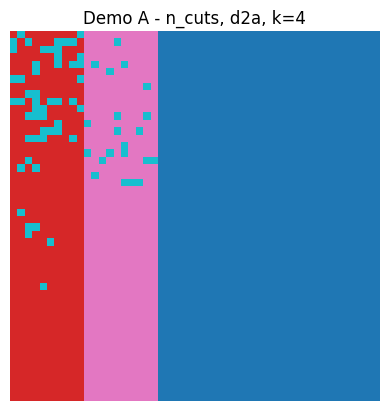

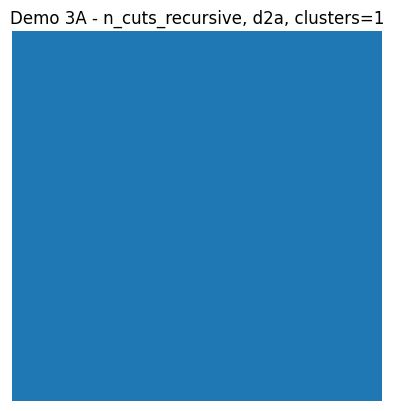

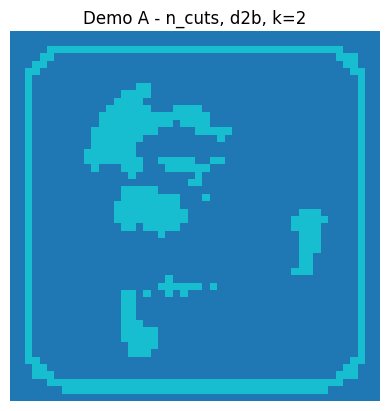

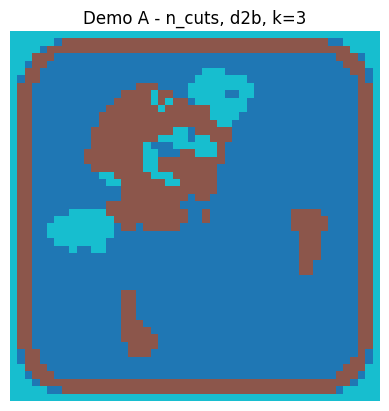

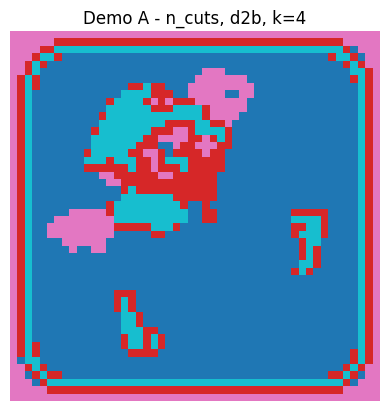

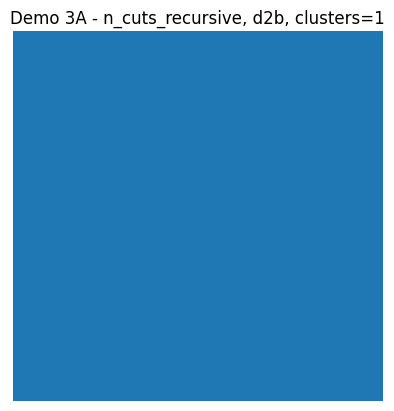

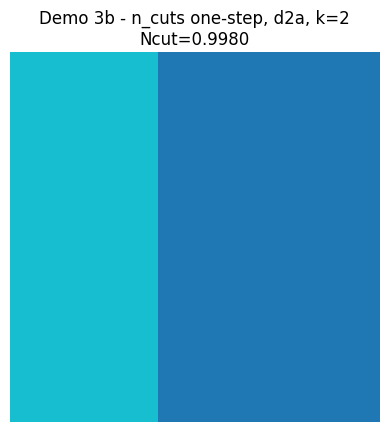

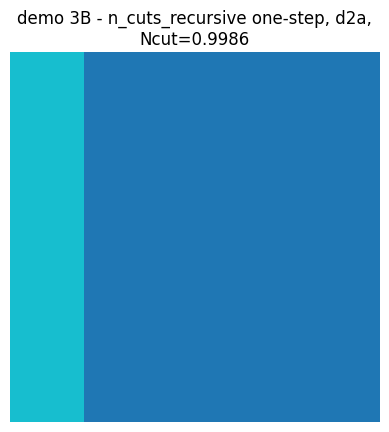

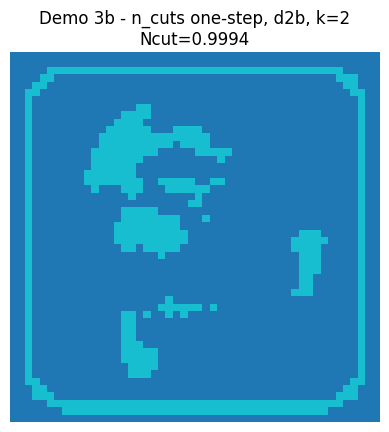

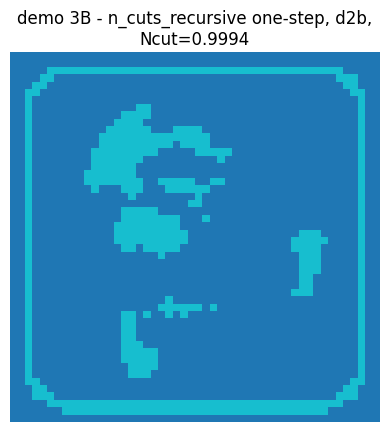

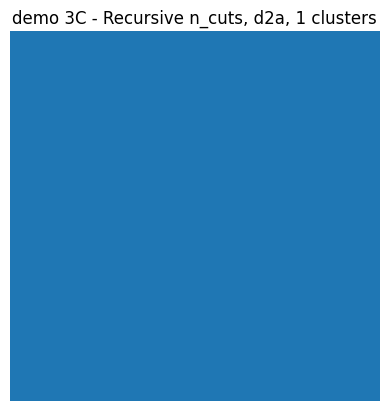

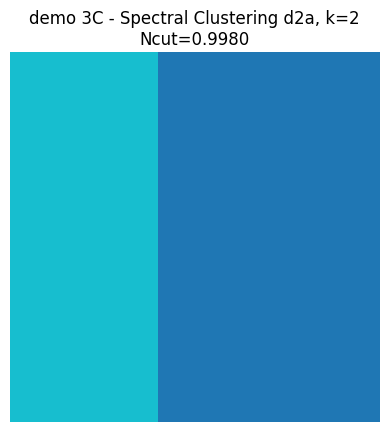

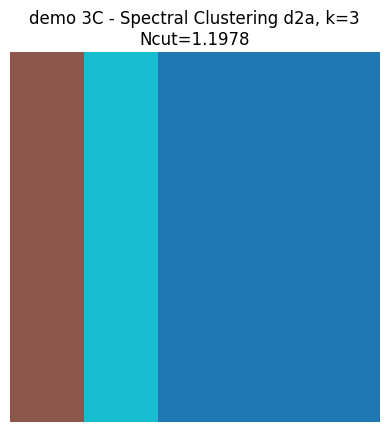

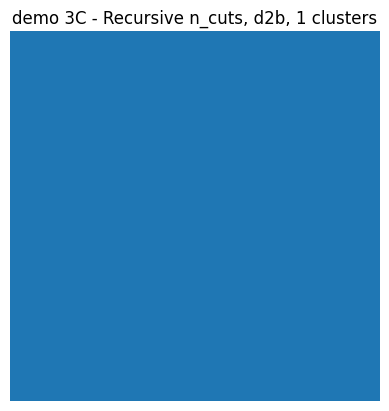

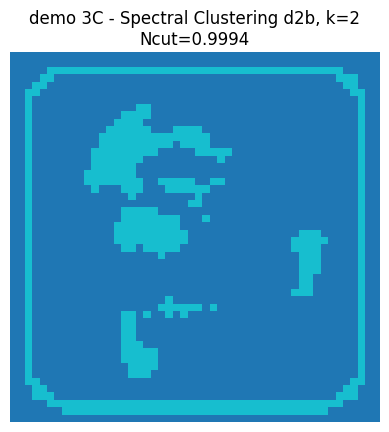

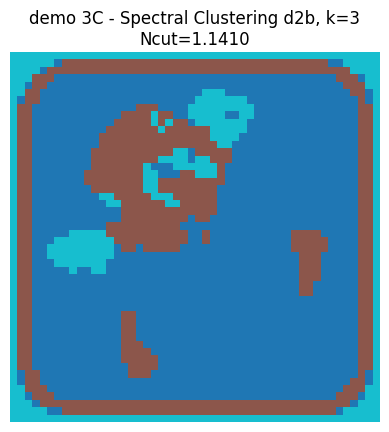

In [ ]:
# Ρυθμίσεις
T1 = 50
T2 = 0.2

# ---------------------------
# Φόρτωση εικόνων
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

mat = loadmat("dip_hw_3.mat")
imgs = {"d2a": mat["d2a"].astype(float) / 255.0,
        "d2b": mat["d2b"].astype(float) / 255.0}

# ---------------------------
# Χαρτογράφηση ετικετών σε εικόνα

def labels_to_image(labels, shape):
    return labels.reshape(shape[:2])

# ---------------------------
# Demo 3a

for name, img in imgs.items():
    print(f"\n--- Image: {name} ---")
    affinity = image_to_graph(img)

    for k in [2, 3, 4]:
        print(f"\n[NCuts] Clustering with k = {k}")
        labels_ncuts = n_cuts(affinity, k)
        clustered_img = labels_to_image(labels_ncuts, img.shape)

        plt.figure()
        plt.imshow(clustered_img, cmap='tab10')
        plt.title(f"Demo 3A - n_cuts, {name}, k={k}")
        plt.axis('off')

        if k == 2:
            ncut_val = calculate_n_cut_value(affinity, labels_ncuts)
            print(f"Ncut value (k=2): {ncut_val:.4f}")

    print("\n[n_cuts_recursive] Recursive clustering:")
    labels_recursive = n_cuts_recursive(affinity, T1=T1, T2=T2)
    clustered_img = labels_to_image(labels_recursive, img.shape)
    num_clusters = len(np.unique(labels_recursive))
    print(f"Generated clusters: {num_clusters}")
    plt.figure()
    plt.imshow(clustered_img, cmap='tab10')
    plt.title(f"Demo 3A - n_cuts_recursive, {name}, clusters={num_clusters}")
    plt.axis('off')

# ---------------------------
# Demo 3b (1 split only)

print("\n--- Demo 3b: One split only ---")
for name, img in imgs.items():
    print(f"\nImage: {name}")
    affinity = image_to_graph(img)

    # NCuts με k=2
    labels_ncuts = n_cuts(affinity, k=2)
    clustered_img = labels_to_image(labels_ncuts, img.shape)
    ncut_val = calculate_n_cut_value(affinity, labels_ncuts)

    plt.figure()
    plt.imshow(clustered_img, cmap='tab10')
    plt.title(f"Demo 3b - n_cuts one-step, {name}, k=2\nNcut={ncut_val:.4f}")
    plt.axis('off')

    # Μη αναδρομική μία διχοτόμηση
    initial_indices = np.arange(affinity.shape[0])
    sub_affinity = affinity[np.ix_(initial_indices, initial_indices)]
    sub_labels = n_cuts(sub_affinity, k=2)
    full_labels = -np.ones(affinity.shape[0], dtype=int)
    full_labels[initial_indices] = sub_labels
    ncut_val_step = calculate_n_cut_value(affinity, full_labels)

    clustered_img = labels_to_image(full_labels, img.shape)
    plt.figure()
    plt.imshow(clustered_img, cmap='tab10')
    plt.title(f"demo 3B - n_cuts_recursive one-step, {name},\nNcut={ncut_val_step:.4f}")
    plt.axis('off')

# ---------------------------
# Demo 3c: Πλήρης αναδρομική n-cuts και σύγκριση με spectral k=2,3

print("\n--- Demo 3c: Full Recursive N-Cuts vs Spectral Clustering ---")

T1 = 5
T2 = 0.20

for name, img in imgs.items():
    print(f"\nImage: {name}")
    affinity = image_to_graph(img)

    # Πλήρης αναδρομική n-cuts
    labels_recursive = n_cuts_recursive(affinity, T1=T1, T2=T2)
    clustered_recursive = labels_to_image(labels_recursive, img.shape)
    n_clusters = len(np.unique(labels_recursive))
    print(f"Recursive n-cuts produced {n_clusters} clusters")

    plt.figure()
    plt.imshow(clustered_recursive, cmap='tab10')
    plt.title(f"demo 3C - Recursive n_cuts, {name}, {n_clusters} clusters")
    plt.axis('off')

    # Σύγκριση με spectral clustering για k=2 και k=3
    for k in [2, 3]:
        labels_k = n_cuts(affinity, k)
        clustered_k = labels_to_image(labels_k, img.shape)
        ncut_val_k = calculate_n_cut_value(affinity, labels_k)

        plt.figure()
        plt.imshow(clustered_k, cmap='tab10')
        plt.title(f"demo 3C - Spectral Clustering {name}, k={k}\nNcut={ncut_val_k:.4f}")
        plt.axis('off')

plt.show()
